# Benchmark of the exhaustive search by N

This notebook has a narrow and practical scope: run the exhaustive search for each diagram size, record execution time, plot the cost curve, and save the results for future reference.

The core logic lives in `src/exhaustive.py`, and this notebook only orchestrates the execution and collects the data.

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

# Discover the project root and insert it in sys.path so the package can be imported
# regardless of how the notebook was launched.
project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("Could not find the src folder from the current working directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.exhaustive import exhaustive_spherical_search


In [ ]:
import csv
import pickle
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.exhaustive import exhaustive_spherical_search

# Find the project root once more in the same robust way, so the notebook can
# save outputs to the expected folders regardless of its launch directory.
project_root = Path.cwd().resolve()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / 'src').exists():
    raise FileNotFoundError('Could not find the src folder from the current working directory.')

results_dir = project_root / 'results'
data_dir = project_root / 'data'
results_dir.mkdir(exist_ok=True)
data_dir.mkdir(exist_ok=True)

print(f'Project root: {project_root}')
print(f'Results folder: {results_dir}')
print(f'Data folder: {data_dir}')


Raiz do projeto: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds
Pasta de resultados: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results
Pasta de dados: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\data


## Experiment setup

Here we define the values of `N` to test and the rule for saving representatives. For small `N`, representatives are very useful for future reference; for `N = 6`, the notebook can follow a leaner mode depending on the available memory budget.

In [ ]:
Ns = list(range(1, 7))
save_representatives_for_n = {1, 2, 3, 4, 5}
summary_path = results_dir / 'exhaustive_summary.csv'

records = []
representatives_by_n = {}

for n in Ns:
    keep_reps = n in save_representatives_for_n
    start = time.perf_counter()
    result = exhaustive_spherical_search(n, keep_representatives=keep_reps)
    elapsed = time.perf_counter() - start

    record = {
        'n': result.n,
        'n_isomorphism_classes': result.n_isomorphism_classes,
        'n_labelled_diagrams': result.n_labelled_diagrams,
        'n_spherical_classes': result.n_spherical_classes,
        'n_spherical_labelled': result.n_spherical_labelled,
        'elapsed_seconds': round(elapsed, 6),
    }
    records.append(record)

    if keep_reps and result.spherical_representatives:
        representatives_by_n[n] = result.spherical_representatives
        reps_path = data_dir / f'representatives_n{n}.pkl'
        with open(reps_path, 'wb') as handle:
            pickle.dump(result.spherical_representatives, handle)
        print(f'Representatives saved for N={n}: {reps_path}')

    print(
        f'N={n}: classes={result.n_isomorphism_classes:>6}, '
        f'labelled={result.n_labelled_diagrams:>12}, '
        f'spherical={result.n_spherical_labelled:>8}, '
        f'time={elapsed:.4f}s'
    )

with open(summary_path, 'w', newline='') as handle:
    writer = csv.DictWriter(
        handle,
        fieldnames=[
            'n',
            'n_isomorphism_classes',
            'n_labelled_diagrams',
            'n_spherical_classes',
            'n_spherical_labelled',
            'elapsed_seconds',
        ],
    )
    writer.writeheader()
    writer.writerows(records)

print(f'\nSummary saved to: {summary_path}')


Arquivos de representantes salvos para N=1: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\data\representatives_n1.pkl
N=1: classes=     1, labelled=           1, spherical=       1, tempo=0.0113s
Arquivos de representantes salvos para N=2: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\data\representatives_n2.pkl
N=2: classes=     4, labelled=           4, spherical=       4, tempo=0.2240s
Arquivos de representantes salvos para N=3: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\data\representatives_n3.pkl
N=3: classes=    20, labelled=          64, spherical=      19, tempo=0.0058s
Arquivos de representantes salvos para N=4: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\data\representatives_n4.pkl
N=4: classes=   276, labelled=        4096, spherical=     134, tempo=0.0104s
Arquivos de representantes salvos para N=5: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\data\representatives_n5.pkl
N=5: classes= 10688, labelled=     1048576, spherical=    1026, temp

## Runtime by N

The time curve is the first piece of evidence for how the exhaustive search scales as the problem size increases. This plot serves as the reference curve for discussing the computational cost and for comparing future optimizations.

Gráfico salvo em: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\exhaustive_runtime.png


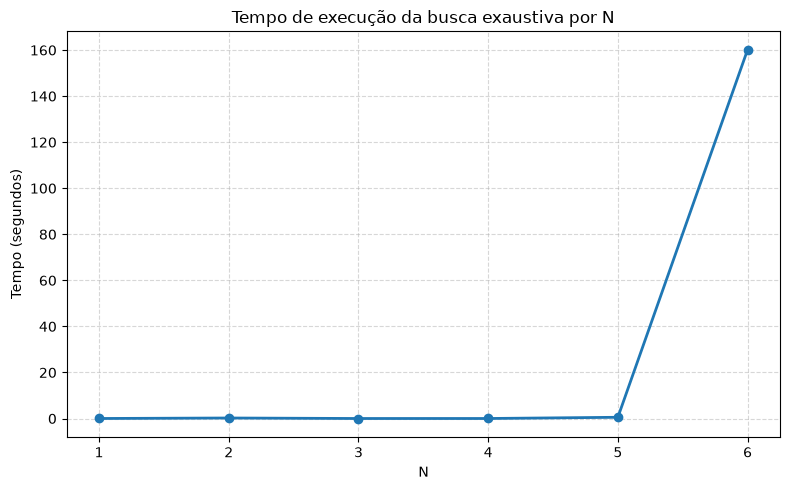

In [ ]:
n_values = [r['n'] for r in records]
time_values = [r['elapsed_seconds'] for r in records]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_values, time_values, marker='o', linewidth=2, color='tab:blue')
ax.set_title('Execution time of the exhaustive search by N')
ax.set_xlabel('N')
ax.set_ylabel('Time (seconds)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

runtime_plot = results_dir / 'exhaustive_runtime_linear.png'
fig.savefig(runtime_plot, dpi=200)
print(f'Linear-scale plot saved to: {runtime_plot}')
plt.show()


## Log-scale view

The runtime growth is best appreciated on a logarithmic scale, since the search space and the cost of isomorphism generation increase very quickly with `N`. A log plot makes the trend more readable.

Log-scale plot saved to: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\exhaustive_runtime_log.png


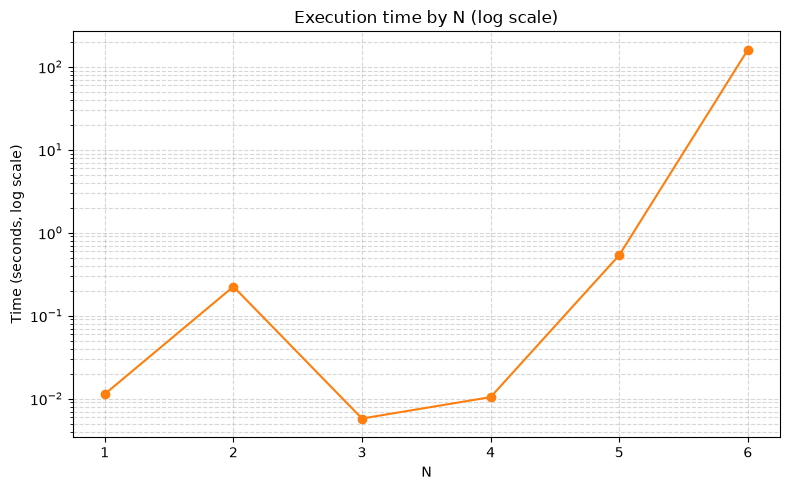


Summary table:
 n  n_isomorphism_classes  n_labelled_diagrams  n_spherical_labelled  elapsed_seconds
 1                      1                    1                     1         0.011344
 2                      4                    4                     4         0.224036
 3                     20                   64                    19         0.005763
 4                    276                 4096                   134         0.010432
 5                  10688              1048576                  1026         0.536149
 6                1601952           1073741824                  9826       160.137673


In [9]:
import pandas as pd

summary_path = results_dir / 'exhaustive_summary.csv'
summary_df = pd.read_csv(summary_path)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(summary_df['n'], summary_df['elapsed_seconds'], marker='o', color='tab:orange')
ax.set_yscale('log')
ax.set_title('Execution time by N (log scale)')
ax.set_xlabel('N')
ax.set_ylabel('Time (seconds, log scale)')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

runtime_log_plot = results_dir / 'exhaustive_runtime_log.png'
fig.savefig(runtime_log_plot, dpi=200)
print(f'Log-scale plot saved to: {runtime_log_plot}')
plt.show()

print('\nSummary table:')
print(summary_df[['n', 'n_isomorphism_classes', 'n_labelled_diagrams', 'n_spherical_labelled', 'elapsed_seconds']].to_string(index=False))
